In [2]:
# Phase 5 – Results Notebook (Standalone)

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path("..").resolve()
summary_path = project_root / "logs" / "organized_data" / "phase5_full_experiment" / "summary.jsonl"

print("project_root:", project_root)
print("summary_path exists:", summary_path.exists())


project_root: C:\Users\ham25\Desktop\Teaching-light-weight-llm-based-project
summary_path exists: True


In [3]:
# Load Phase 5 summary and flatten to df_flat

records = []
with summary_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

cfg = df["config"].apply(pd.Series)
metrics = df["metrics"].apply(pd.Series)

df_flat = pd.concat([df.drop(columns=["config", "metrics"]), cfg, metrics], axis=1)

# Convenience columns
df_flat["tokens_per_question"] = df_flat["student_teacher_tokens"] / 100.0
df_flat["student_tokens_per_q"] = df_flat["student_tokens_total"] / 100.0
df_flat["teacher_tokens_per_q"] = df_flat["teacher_tokens_total"] / 100.0

df_flat["has_teacher"] = df_flat["teacher"].notna()
df_flat["memory"] = df_flat["mode"].map(
    {
        "baseline": "OFF",
        "champion_mem_on": "ON",
        "champion_mem_off": "OFF",
    }
)

domain_order = {"alpaca": 0, "medical": 1}
mode_order = {"baseline": 0, "champion_mem_on": 1, "champion_mem_off": 2}

df_flat["domain_order"] = df_flat["domain"].map(domain_order)
df_flat["mode_order"] = df_flat["mode"].map(mode_order)
df_flat = df_flat.sort_values(["domain_order", "mode_order"]).reset_index(drop=True)

def make_label(row):
    dom = "Alpaca" if row["domain"] == "alpaca" else "Medical"
    if row["mode"] == "baseline":
        return f"{dom}\nBaseline"
    elif row["mode"] == "champion_mem_on":
        return f"{dom}\nChampion+MemON"
    else:
        return f"{dom}\nChampion+MemOFF"

df_flat["exp_label"] = df_flat.apply(make_label, axis=1)

df_flat


,experiment_id,phase,avg_rounds,memory_hits,memory_hit_rate,student_tokens_total,teacher_tokens_total,student_teacher_tokens,timestamp,seed,...,blind_judge,comparison_judge,tokens_per_question,student_tokens_per_q,teacher_tokens_per_q,has_teacher,memory,domain_order,mode_order,exp_label
0,phase5_baseline_alpaca_100,phase5,1.00,0,0.00,13857,0,13857,2025-11-19T13:34:49.694803,42,...,0.0000,0.000,138.57,138.57,0.00,False,OFF,0,0,Alpaca\nBaseline
1,phase5_champion_mem_on_alpaca_100,phase5,6.34,5,0.05,207941,344314,552255,2025-11-19T14:24:20.695264,42,...,0.8555,0.972,5522.55,2079.41,3443.14,True,ON,0,1,Alpaca\nChampion+MemON
2,phase5_champion_mem_off_alpaca_100,phase5,6.53,0,0.00,213510,358455,571965,2025-11-19T15:08:15.705226,42,...,0.8545,0.960,5719.65,2135.10,3584.55,True,OFF,0,2,Alpaca\nChampion+MemOFF
3,phase5_baseline_medical_100,phase5,1.00,0,0.00,17152,0,17152,2025-11-19T13:42:19.997489,42,...,0.0000,0.000,171.52,171.52,0.00,False,OFF,1,0,Medical\nBaseline
4,phase5_champion_mem_on_medical_100,phase5,9.23,12,0.12,415432,794001,1209433,2025-11-19T16:22:05.937582,42,...,0.8620,0.940,12094.33,4154.32,7940.01,True,ON,1,1,Medical\nChampion+MemON
5,phase5_champion_mem_off_medical_100,phase5,9.20,0,0.00,421575,794868,1216443,2025-11-19T17:36:08.504550,42,...,0.8660,0.939,12164.43,4215.75,7948.68,True,OFF,1,2,Medical\nChampion+MemOFF


In [4]:
# Load Phase 5 summary and flatten to df_flat

records = []
with summary_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

cfg = df["config"].apply(pd.Series)
metrics = df["metrics"].apply(pd.Series)

df_flat = pd.concat([df.drop(columns=["config", "metrics"]), cfg, metrics], axis=1)

# Convenience columns
df_flat["tokens_per_question"] = df_flat["student_teacher_tokens"] / 100.0
df_flat["student_tokens_per_q"] = df_flat["student_tokens_total"] / 100.0
df_flat["teacher_tokens_per_q"] = df_flat["teacher_tokens_total"] / 100.0

df_flat["has_teacher"] = df_flat["teacher"].notna()
df_flat["memory"] = df_flat["mode"].map(
    {
        "baseline": "OFF",
        "champion_mem_on": "ON",
        "champion_mem_off": "OFF",
    }
)

domain_order = {"alpaca": 0, "medical": 1}
mode_order = {"baseline": 0, "champion_mem_on": 1, "champion_mem_off": 2}

df_flat["domain_order"] = df_flat["domain"].map(domain_order)
df_flat["mode_order"] = df_flat["mode"].map(mode_order)
df_flat = df_flat.sort_values(["domain_order", "mode_order"]).reset_index(drop=True)

def make_label(row):
    dom = "Alpaca" if row["domain"] == "alpaca" else "Medical"
    if row["mode"] == "baseline":
        return f"{dom}\nBaseline"
    elif row["mode"] == "champion_mem_on":
        return f"{dom}\nChampion+MemON"
    else:
        return f"{dom}\nChampion+MemOFF"

df_flat["exp_label"] = df_flat.apply(make_label, axis=1)

df_flat


,experiment_id,phase,avg_rounds,memory_hits,memory_hit_rate,student_tokens_total,teacher_tokens_total,student_teacher_tokens,timestamp,seed,...,blind_judge,comparison_judge,tokens_per_question,student_tokens_per_q,teacher_tokens_per_q,has_teacher,memory,domain_order,mode_order,exp_label
0,phase5_baseline_alpaca_100,phase5,1.00,0,0.00,13857,0,13857,2025-11-19T13:34:49.694803,42,...,0.0000,0.000,138.57,138.57,0.00,False,OFF,0,0,Alpaca\nBaseline
1,phase5_champion_mem_on_alpaca_100,phase5,6.34,5,0.05,207941,344314,552255,2025-11-19T14:24:20.695264,42,...,0.8555,0.972,5522.55,2079.41,3443.14,True,ON,0,1,Alpaca\nChampion+MemON
2,phase5_champion_mem_off_alpaca_100,phase5,6.53,0,0.00,213510,358455,571965,2025-11-19T15:08:15.705226,42,...,0.8545,0.960,5719.65,2135.10,3584.55,True,OFF,0,2,Alpaca\nChampion+MemOFF
3,phase5_baseline_medical_100,phase5,1.00,0,0.00,17152,0,17152,2025-11-19T13:42:19.997489,42,...,0.0000,0.000,171.52,171.52,0.00,False,OFF,1,0,Medical\nBaseline
4,phase5_champion_mem_on_medical_100,phase5,9.23,12,0.12,415432,794001,1209433,2025-11-19T16:22:05.937582,42,...,0.8620,0.940,12094.33,4154.32,7940.01,True,ON,1,1,Medical\nChampion+MemON
5,phase5_champion_mem_off_medical_100,phase5,9.20,0,0.00,421575,794868,1216443,2025-11-19T17:36:08.504550,42,...,0.8660,0.939,12164.43,4215.75,7948.68,True,OFF,1,2,Medical\nChampion+MemOFF


In [5]:
# Main result table
main_cols = [
    "experiment_id",
    "domain",
    "mode",
    "exact_match",
    "rouge_l",
    "semantic_similarity",
    "blind_judge",
    "comparison_judge",
    "avg_rounds",
    "student_tokens_total",
    "teacher_tokens_total",
    "student_teacher_tokens",
    "tokens_per_question",
]
display(df_flat[main_cols])

# Improvement vs baseline per domain
rows = []
for dom in df_flat["domain"].unique():
    sub = df_flat[df_flat["domain"] == dom]
    base = sub[sub["mode"] == "baseline"].iloc[0]
    for _, r in sub.iterrows():
        if r["mode"] == "baseline":
            continue
        rows.append(
            {
                "domain": dom,
                "mode": r["mode"],
                "experiment_id": r["experiment_id"],
                "EM_baseline": base["exact_match"],
                "EM": r["exact_match"],
                "ROUGE_baseline": base["rouge_l"],
                "ROUGE": r["rouge_l"],
                "Sem_baseline": base["semantic_similarity"],
                "Sem": r["semantic_similarity"],
                "Comp_baseline": base["comparison_judge"],
                "Comp": r["comparison_judge"],
                "tokens_per_q_baseline": base["tokens_per_question"],
                "tokens_per_q": r["tokens_per_question"],
            }
        )

df_improve = pd.DataFrame(rows)
display(df_improve)


,experiment_id,domain,mode,exact_match,rouge_l,semantic_similarity,blind_judge,comparison_judge,avg_rounds,student_tokens_total,teacher_tokens_total,student_teacher_tokens,tokens_per_question
0,phase5_baseline_alpaca_100,alpaca,baseline,0.07,0.440997,0.720155,0.0000,0.000,1.00,13857,0,13857,138.57
1,phase5_champion_mem_on_alpaca_100,alpaca,champion_mem_on,0.66,0.905117,0.963665,0.8555,0.972,6.34,207941,344314,552255,5522.55
2,phase5_champion_mem_off_alpaca_100,alpaca,champion_mem_off,0.62,0.909448,0.959462,0.8545,0.960,6.53,213510,358455,571965,5719.65
3,phase5_baseline_medical_100,medical,baseline,0.00,0.145547,0.702229,0.0000,0.000,1.00,17152,0,17152,171.52
4,phase5_champion_mem_on_medical_100,medical,champion_mem_on,0.37,0.745957,0.934258,0.8620,0.940,9.23,415432,794001,1209433,12094.33
5,phase5_champion_mem_off_medical_100,medical,champion_mem_off,0.37,0.748061,0.941712,0.8660,0.939,9.20,421575,794868,1216443,12164.43


,domain,mode,experiment_id,EM_baseline,EM,ROUGE_baseline,ROUGE,Sem_baseline,Sem,Comp_baseline,Comp,tokens_per_q_baseline,tokens_per_q
0,alpaca,champion_mem_on,phase5_champion_mem_on_alpaca_100,0.07,0.66,0.440997,0.905117,0.720155,0.963665,0.0,0.972,138.57,5522.55
1,alpaca,champion_mem_off,phase5_champion_mem_off_alpaca_100,0.07,0.62,0.440997,0.909448,0.720155,0.959462,0.0,0.960,138.57,5719.65
2,medical,champion_mem_on,phase5_champion_mem_on_medical_100,0.00,0.37,0.145547,0.745957,0.702229,0.934258,0.0,0.940,171.52,12094.33
3,medical,champion_mem_off,phase5_champion_mem_off_medical_100,0.00,0.37,0.145547,0.748061,0.702229,0.941712,0.0,0.939,171.52,12164.43


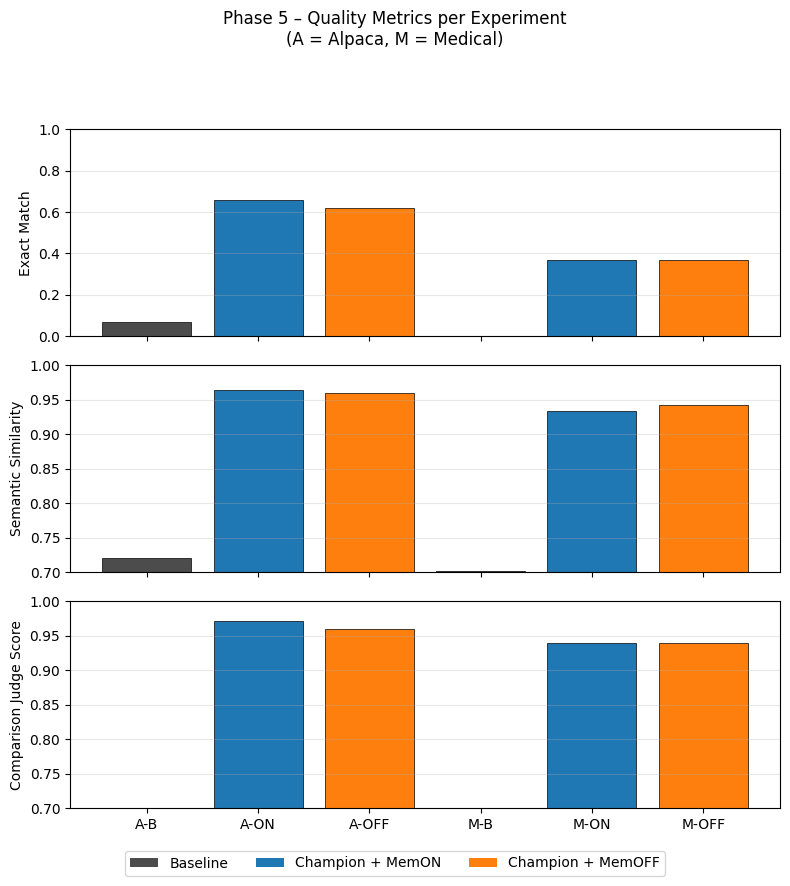

In [6]:
# D3 – Phase 5 Multi-metric overview (legend ด้านล่าง)

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def make_short_code(row):
    dom = "A" if row["domain"] == "alpaca" else "M"
    if row["mode"] == "baseline":
        return f"{dom}-B"
    elif row["mode"] == "champion_mem_on":
        return f"{dom}-ON"
    else:
        return f"{dom}-OFF"

df_flat["exp_code"] = df_flat.apply(make_short_code, axis=1)

mode_colors = {
    "baseline": "#4c4c4c",           # dark gray
    "champion_mem_on": "#1f77b4",    # blue
    "champion_mem_off": "#ff7f0e",   # orange
}
colors = df_flat["mode"].map(mode_colors)

x = range(len(df_flat))
labels = df_flat["exp_code"]

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

metrics = [
    ("exact_match", "Exact Match", (0.0, 1.0)),
    ("semantic_similarity", "Semantic Similarity", (0.7, 1.0)),
    ("comparison_judge", "Comparison Judge Score", (0.7, 1.0)),
]

for ax, (col, title, ylim) in zip(axes, metrics):
    ax.bar(x, df_flat[col], color=colors, edgecolor="black", linewidth=0.5)
    ax.set_ylabel(title)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)

legend_elems = [
    Patch(facecolor=mode_colors["baseline"], label="Baseline"),
    Patch(facecolor=mode_colors["champion_mem_on"], label="Champion + MemON"),
    Patch(facecolor=mode_colors["champion_mem_off"], label="Champion + MemOFF"),
]
# legend ล่างสุด
fig.legend(handles=legend_elems, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.01))

fig.suptitle("Phase 5 – Quality Metrics per Experiment\n(A = Alpaca, M = Medical)", y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()


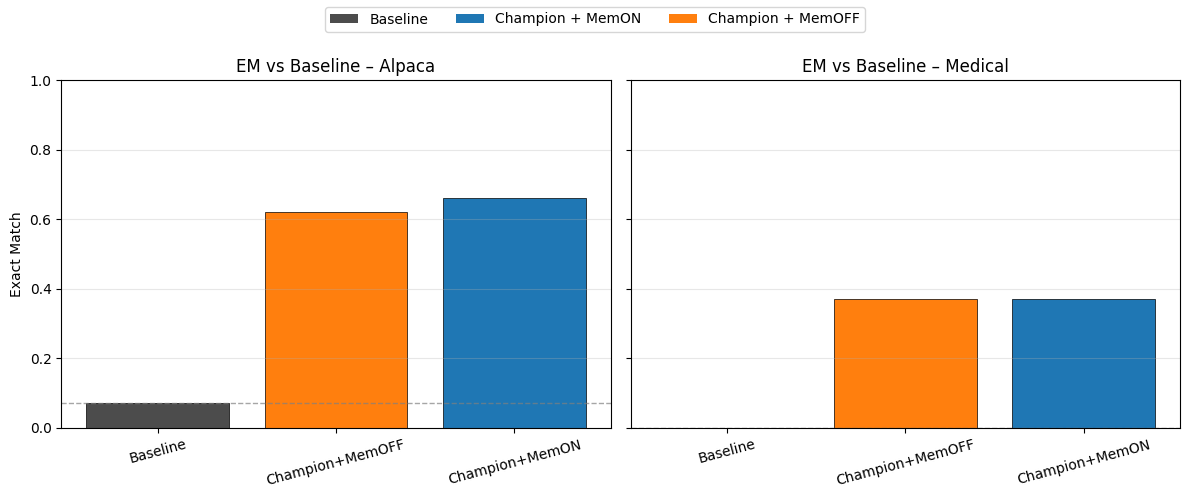

In [7]:
# Phase 5 – EM vs Baseline per domain

rows = []
for dom in df_flat["domain"].unique():
    sub = df_flat[df_flat["domain"] == dom]
    base = sub[sub["mode"] == "baseline"].iloc[0]
    off = sub[sub["mode"] == "champion_mem_off"].iloc[0]
    on  = sub[sub["mode"] == "champion_mem_on"].iloc[0]
    rows.append({"domain": dom, "config": "Baseline",        "EM": base["exact_match"]})
    rows.append({"domain": dom, "config": "Champion+MemOFF", "EM": off["exact_match"]})
    rows.append({"domain": dom, "config": "Champion+MemON",  "EM": on["exact_match"]})

df_em = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, dom in zip(axes, ["alpaca", "medical"]):
    sub = df_em[df_em["domain"] == dom]
    x_dom = range(len(sub))

    colors_dom = []
    for cfg in sub["config"]:
        if cfg == "Baseline":
            colors_dom.append(mode_colors["baseline"])
        elif "OFF" in cfg:
            colors_dom.append(mode_colors["champion_mem_off"])
        else:
            colors_dom.append(mode_colors["champion_mem_on"])

    ax.bar(x_dom, sub["EM"], color=colors_dom, edgecolor="black", linewidth=0.5)
    em_base = float(sub[sub["config"] == "Baseline"]["EM"].iloc[0])
    ax.axhline(em_base, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_xticks(x_dom)
    ax.set_xticklabels(sub["config"], rotation=15)
    ax.set_ylim(0.0, 1.0)
    dom_title = "Alpaca" if dom == "alpaca" else "Medical"
    ax.set_title(f"EM vs Baseline – {dom_title}")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Exact Match")

fig.legend(handles=legend_elems, loc="upper center", ncol=3)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


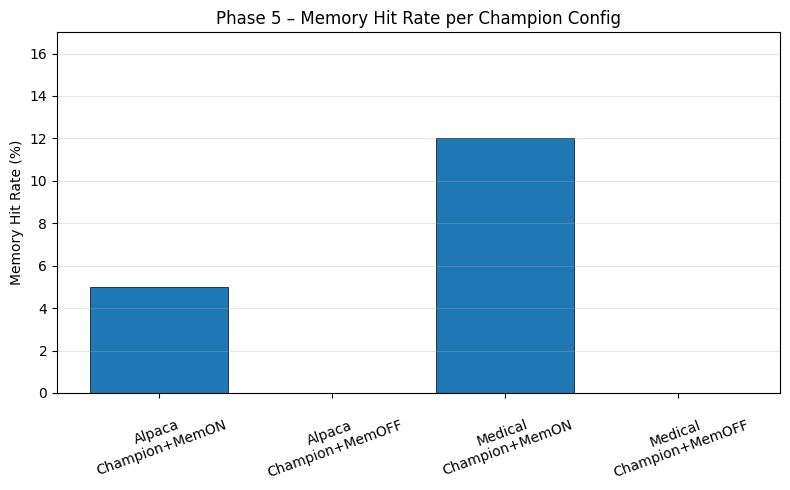

In [8]:
# Phase 5 – Memory Hit Rate (champion only)

df_ch = df_flat[df_flat["mode"] != "baseline"].copy()

plt.figure(figsize=(8, 5))
colors_ch = df_ch["mode"].map(mode_colors)

plt.bar(df_ch["exp_label"], df_ch["memory_hit_rate"] * 100.0, color=colors_ch, edgecolor="black", linewidth=0.5)

plt.ylabel("Memory Hit Rate (%)")
plt.title("Phase 5 – Memory Hit Rate per Champion Config")
plt.ylim(0, max(5, (df_ch["memory_hit_rate"] * 100.0).max() + 5))
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


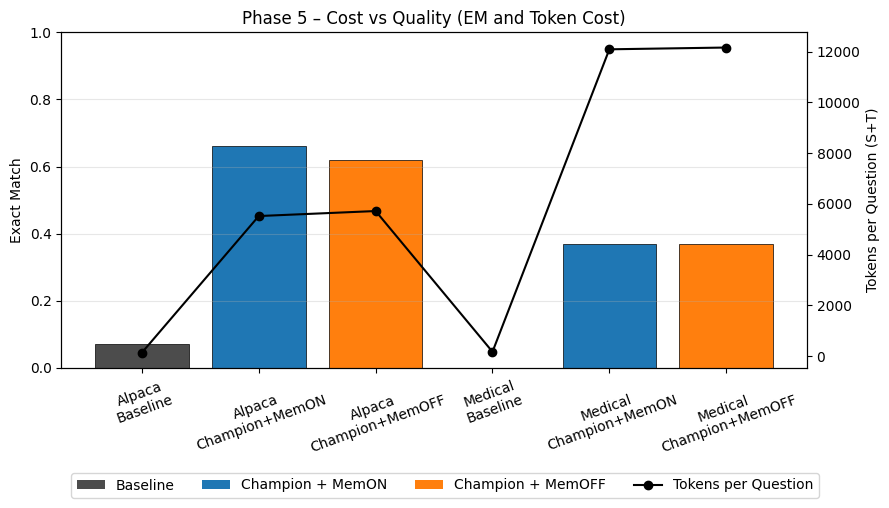

In [9]:
# Phase 5 – Cost vs Quality (EM + Tokens per Question)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax1 = plt.subplots(figsize=(9, 5))

x = range(len(df_flat))
labels = df_flat["exp_label"]
colors = df_flat["mode"].map(mode_colors)

# แกนซ้าย: EM (bar)
bars = ax1.bar(x, df_flat["exact_match"], color=colors, edgecolor="black", linewidth=0.5)
ax1.set_ylabel("Exact Match")
ax1.set_ylim(0.0, 1.0)
ax1.grid(axis="y", alpha=0.3)

# แกนขวา: Tokens per Question (line)
ax2 = ax1.twinx()
line = ax2.plot(x, df_flat["tokens_per_question"], color="black", marker="o", linewidth=1.5)[0]
ax2.set_ylabel("Tokens per Question (S+T)")

ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20)

# Legend รวมไว้ด้านล่าง
legend_mode = [
    Patch(facecolor=mode_colors["baseline"], label="Baseline"),
    Patch(facecolor=mode_colors["champion_mem_on"], label="Champion + MemON"),
    Patch(facecolor=mode_colors["champion_mem_off"], label="Champion + MemOFF"),
]
line_legend = Line2D([0], [0], color="black", marker="o", linestyle="-", label="Tokens per Question")

all_handles = legend_mode + [line_legend]
fig.legend(handles=all_handles, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))

plt.title("Phase 5 – Cost vs Quality (EM and Token Cost)")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


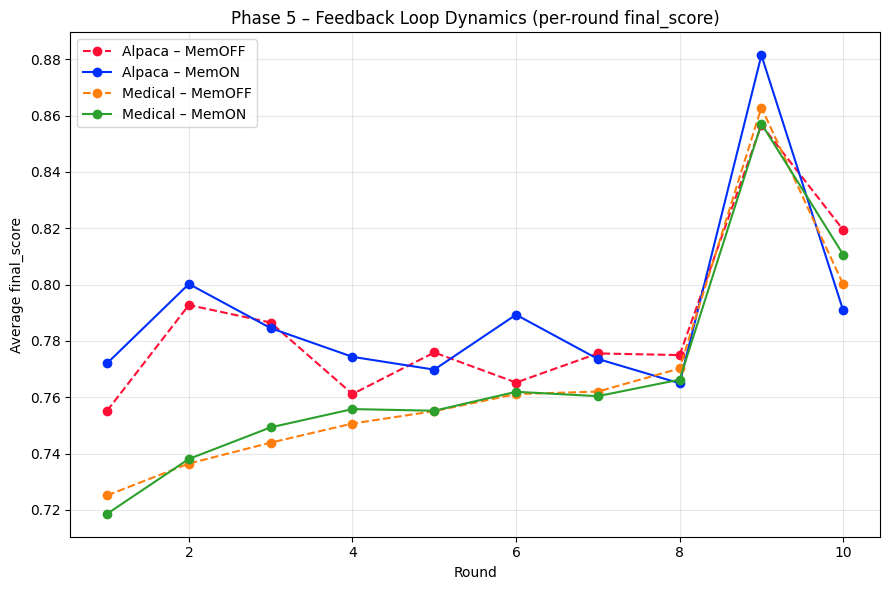

In [10]:
# Phase 5 – Per-round feedback dynamics (final_score vs round)

rounds_path = project_root / "logs" / "phase5_full_experiment" / "debug_per_round.jsonl"
df_rounds = pd.read_json(rounds_path, lines=True)

df_rounds_ch = df_rounds[df_rounds["mode"].str.startswith("champion_")].copy()

g = (
    df_rounds_ch
    .groupby(["domain", "mode", "round"])["final_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))

style_map = {
    ("alpaca", "champion_mem_on"): ("Alpaca – MemON", "#002efa"),
    ("alpaca", "champion_mem_off"): ("Alpaca – MemOFF", "#ff0e36"),
    ("medical", "champion_mem_on"): ("Medical – MemON", "#2ca02c"),
    ("medical", "champion_mem_off"): ("Medical – MemOFF", "#ff7f0e"),
}

for (dom, mode), grp in g.groupby(["domain", "mode"]):
    label, color = style_map[(dom, mode)]
    linestyle = "-" if "mem_on" in mode else "--"
    plt.plot(grp["round"], grp["final_score"], marker="o", label=label, color=color, linestyle=linestyle)
    

plt.xlabel("Round")
plt.ylabel("Average final_score")
plt.title("Phase 5 – Feedback Loop Dynamics (per-round final_score)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
